<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 11 </b></center>
<center><b><h5>K-means, K-Medoids</b></center>
<pre>    

# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Step 2: Load the Dataset
Load Given dataset -  StudentsPerformance.csv

In [2]:
df = pd.read_csv('StudentsPerformance.csv')

In [3]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


# Step 3: Data Overview
In this step, we examine the dataset structure, summary statistics, and check for missing values.

In [4]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# Step 4: Display PairPlot

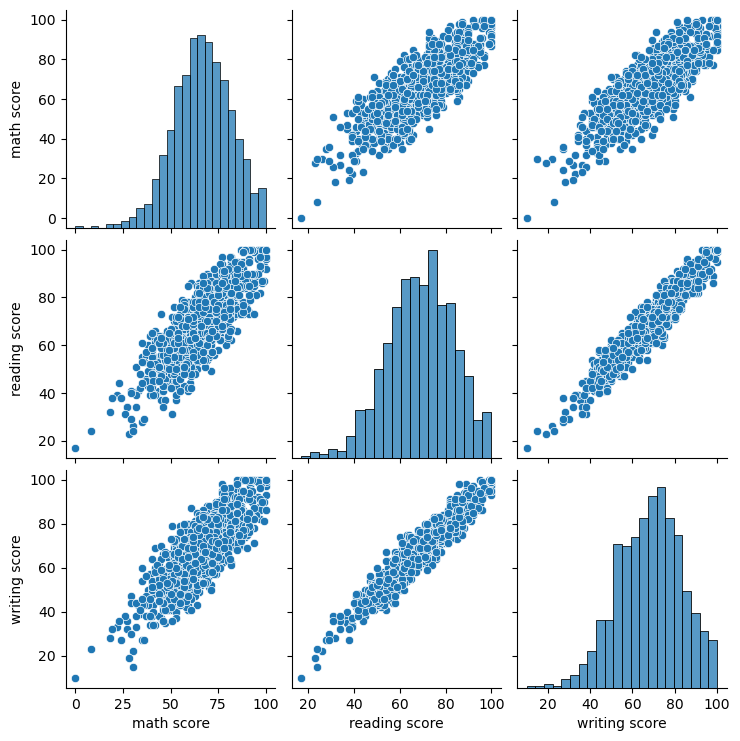

In [7]:
sns.pairplot(df)

# Step 5: Correlation heatmap

<Axes: >

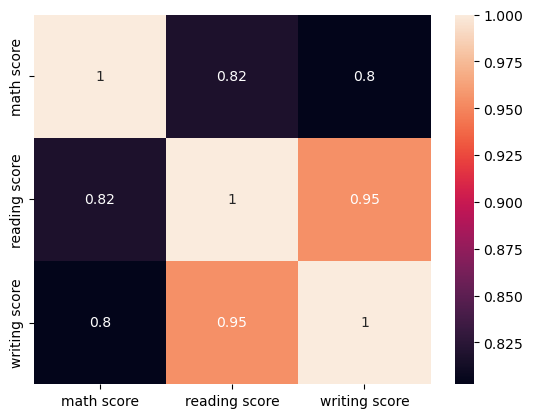

In [8]:
df_sel = df.select_dtypes(include=[np.number])
sns.heatmap(df_sel.corr(),annot=True)

# Step 6: Distribution of numerical features

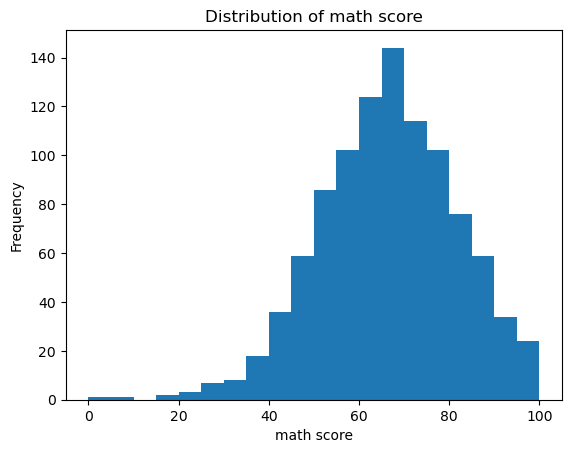

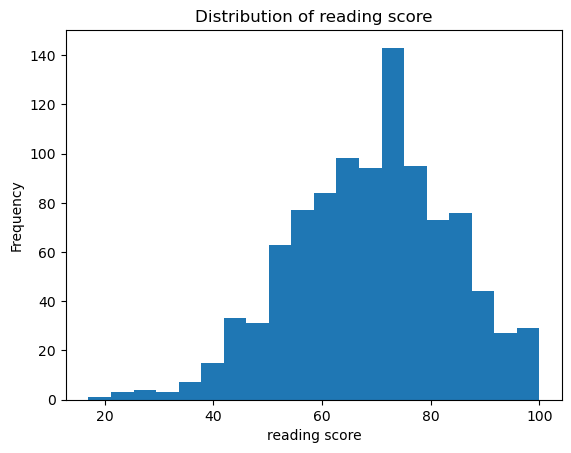

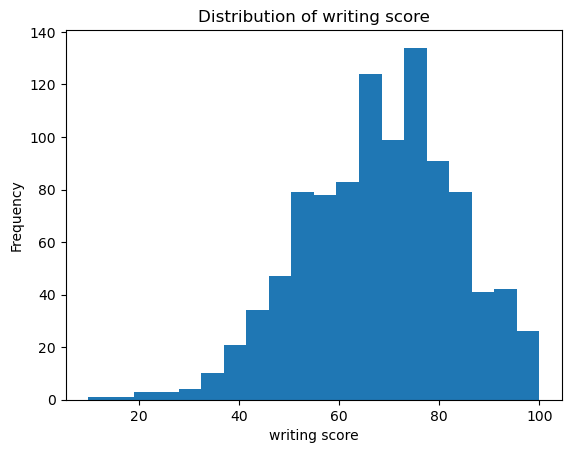

In [9]:
columns = df.select_dtypes(include=[np.number])
for col in columns:
    plt.figure()
    plt.hist(df[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Step 7: Apply StandardScaler

In [10]:
x = df[['math score','reading score','writing score']]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_scaled_df = pd.DataFrame(x_scaled, columns=x.columns)
print(x_scaled_df.head())

   math score  reading score  writing score
0    0.390024       0.193999       0.391492
1    0.192076       1.427476       1.313269
2    1.577711       1.770109       1.642475
3   -1.259543      -0.833899      -1.583744
4    0.653954       0.605158       0.457333


# Step 8: Elbow method to find optimal k

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

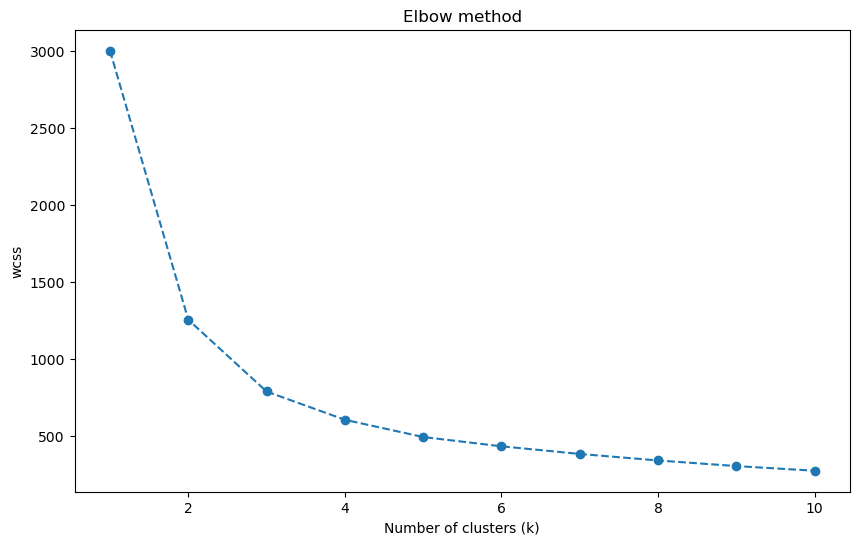

[3000.0, 1253.8571144508817, 788.3656838915331, 604.921239013084, 492.95066485513536, 432.715836247986, 383.1368293631918, 340.83420663005575, 304.3486391178841, 274.2000202706408]


In [11]:
wcss = []
k_range = range(1,11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('wcss')
plt.show()

print(wcss)

# Step 9:Based on the elbow plot, choose an appropriate k value (e.g., k=3)

In [12]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(x_scaled)

df['cluster'] = clusters

df.head()

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,cluster
0,female,group B,bachelor's degree,standard,none,72,72,74,0
1,female,group C,some college,standard,completed,69,90,88,2
2,female,group B,master's degree,standard,none,90,95,93,2
3,male,group A,associate's degree,free/reduced,none,47,57,44,1
4,male,group C,some college,standard,none,76,78,75,2


# Step 10: Print Cluster Center

In [20]:
centers_scaled = print(kmeans.cluster_centers_)
centers_scaled


centers_org = print(scaler.inverse_transform(kmeans.cluster_centers_))
centers_org

[[-0.04951336 -0.04870596 -0.01529686]
 [-1.18720058 -1.26762535 -1.28838441]
 [ 1.03099793  1.09485536  1.06358515]]
[[65.33860045 68.45823928 67.82167043]
 [48.09638554 50.67068273 48.48594378]
 [81.71428571 85.1461039  84.20779221]]


# Step 11:Analyze clusters 

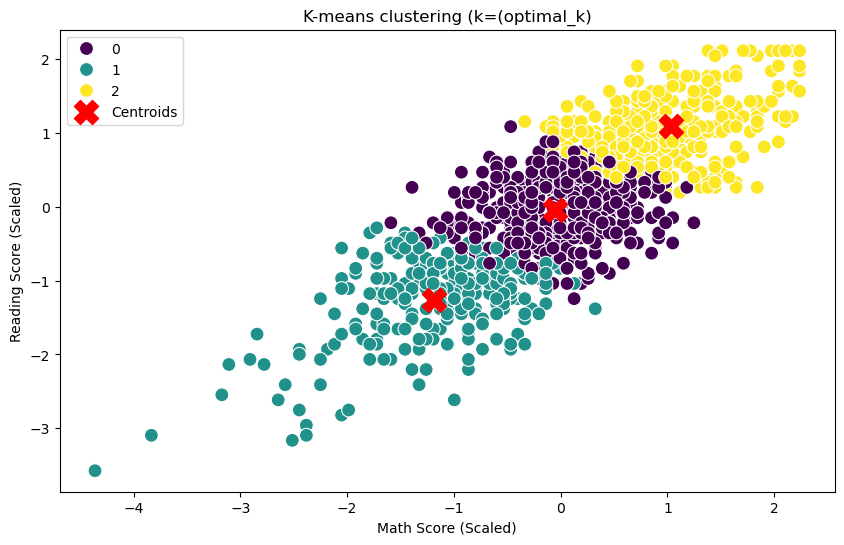

In [24]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=x_scaled[:,0], y=x_scaled[:,1], hue=clusters, palette='viridis', s=100)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=300, c='red', marker='X', label='Centroids')
plt.title(f'K-means clustering (k=(optimal_k)')
plt.xlabel('Math Score (Scaled)')
plt.ylabel('Reading Score (Scaled)')
plt.legend()
plt.show()

# Step 12: Perform K-Medoids

In [1]:
from sklearn_extra.cluster import KMedoids

ModuleNotFoundError: No module named 'sklearn_extra'

In [ ]:
kmedoids = kMedoids(n_clusters=optimal_k, random_state=42, method='pam')
y_kmedoids = kmedoids.fit_predict(x_scaled)

df['Cluster_KMedoids'] = y_kmedoids
print(f'kmedoids fitted successfully')

plt.figure(figsize=(10,6))
sns.scatterplot(x=x_scaled[:,0], y=x_scaled[:,1], hue=y_kmedoids, palette='deep', s=100)

plt.scatter(kmedoids.cluster_centers_[:,0], kmedoids.cluster_centers_[:,1], s=300, marker='X', label='Medoids')

plt.title(f'K-Medoids Clustering (k=(optimal_k)')
plt.xlabel('Math Score (Scaled)')
plt.ylabel('Reading Score (Scaled)')
plt.legend()
plt.show()

# Step 13: Comparison of K-means and K-medoids Clusters

In [ ]:
print('K-Means Cluster Counts')
print(df['cluster'].value_counts().sort_index())

print('\nK-Medoids Cluster Counts')
print(df['Cluster_KMedoids'].value_counts().sort_index())

print('\nK_Means Centroids (Original Scale)')
print(scaler.inverse_transform(kmeans.cluster_centers_))

print('\nK-Medoids Centroids (Original Scale)')
print(scaler.inverse_transform(kmedoids.cluster_centers_))

# Step 14: | USE KMEAN++


In [ ]:
kmeans_plus = KMeans(n_clusters=optimal_k, init='kmeans++', random_state=42, n_init=10)
y_kmeans_plus = kmeans_plus.predict(x_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(x=x_scaled[:,0], y=x_scaled[:,1], hue=y_kmeans_plus, palette='rocket', s=100)

plt.scatter(kmeans_plus.cluster_centers_[:,0], kmeans_plus.cluster_centers_[:,1], s=300, c='blue', markers='*', label='Centroids (KMeans++)')

plt.title(f'K-Means++ Clustering (k=(optimal_k)')
plt.xlabel('Math Score (Scaled)')
plt.ylabel('Reading Score (Scaled)')
plt.legend()
plt.show()